# EX 5.2 : Unsupervised classification

## Background
In the previous exercise, we performed data exploration to get an idea on which features could help distinguish the different sleep stages. In this exercise, we will try to automatically classify samples into these different sleep stages, without using any labels. We call this unsupervised classification.

**Unsupervised classification** achieves separation by finding hidden structure in the unlabeled data. K-means clustering is a popular method to perform unsupervised classification. K-means clustering aims to partition the samples into K clusters in which each sample belongs to the cluster with the nearest centroid.


In [ ]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
import os
%matplotlib inline
import zipfile
from sklearn.cluster import KMeans

## 2.1 K-means clustering

### Load data

Reuse the features and labels from task 1. **Copy your code** from the first exercise to load the data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/new /EX5: Introduction to classification and pattern recognition"
zip_path = os.path.join(base_path, "data.zip")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print("Extracted files:")
print(os.listdir(base_path))

sleep_path = os.path.join(base_path, "EEG_sleep")
sup_path   = os.path.join(base_path, "EEG_sleep_supervised")

print("EEG_SLEEP:", os.listdir(sleep_path))
print("EEG_SLEEP_SUPERVISED:", os.listdir(sup_path))

# Load the features and labels
# features = np.load('features.npy')
# labels = np.load('labels.npy')
features = np.load(os.path.join(sleep_path, "features.npy"))
labels   = np.load(os.path.join(sleep_path, "labels.npy"))
labels = np.squeeze(labels)

# features is a numpy array with shape (n_samples, n_features)
# labels is a numpy array with shape (n_samples,)

print(features, features.shape)
print(labels, labels.shape)

# Define the names of the features and the classes.
feature_names = ['Relative Delta power','Relative Theta power','Relative Alpha power','Relative Beta power']
sleep_stages = ['N3','N2','N1','REM','Wake']

Extracted files:
['5.3. Supervised classification.ipynb', 'data.zip', 'EEG_sleep', 'EEG_sleep_supervised', '5.1. Descriptive statistics.ipynb', '5.2. Unsupervised Classification.ipynb']
EEG_SLEEP: ['features.npy', 'labels.npy']
EEG_SLEEP_SUPERVISED: ['feat_test.npy', 'labels_train.npy', 'labels_test.npy', 'feat_train.npy']
[[-1.46191566 -1.5010528  -1.47646705  2.48126252]
 [ 1.3430578  -1.98996591 -1.91849654 -0.4174545 ]
 [ 0.82336493 -1.40047083 -1.5178862  -0.1181919 ]
 ...
 [-0.94790772  1.29882765  0.21047252  0.59063583]
 [-0.54798103  0.15478108  1.24472578  0.28225901]
 [-0.99539705  0.35649881  0.37938277  0.91732991]] (1026, 4)
[5 5 5 ... 5 5 5] (1026,)


### Feature Visualization

**Revisit the scatter plots** of the different classes for each combination of features from exercise 1. Can you find clusters of the different sleep stages?

If you want, you can copy your code from exercise 1 and regenerate the figure here.

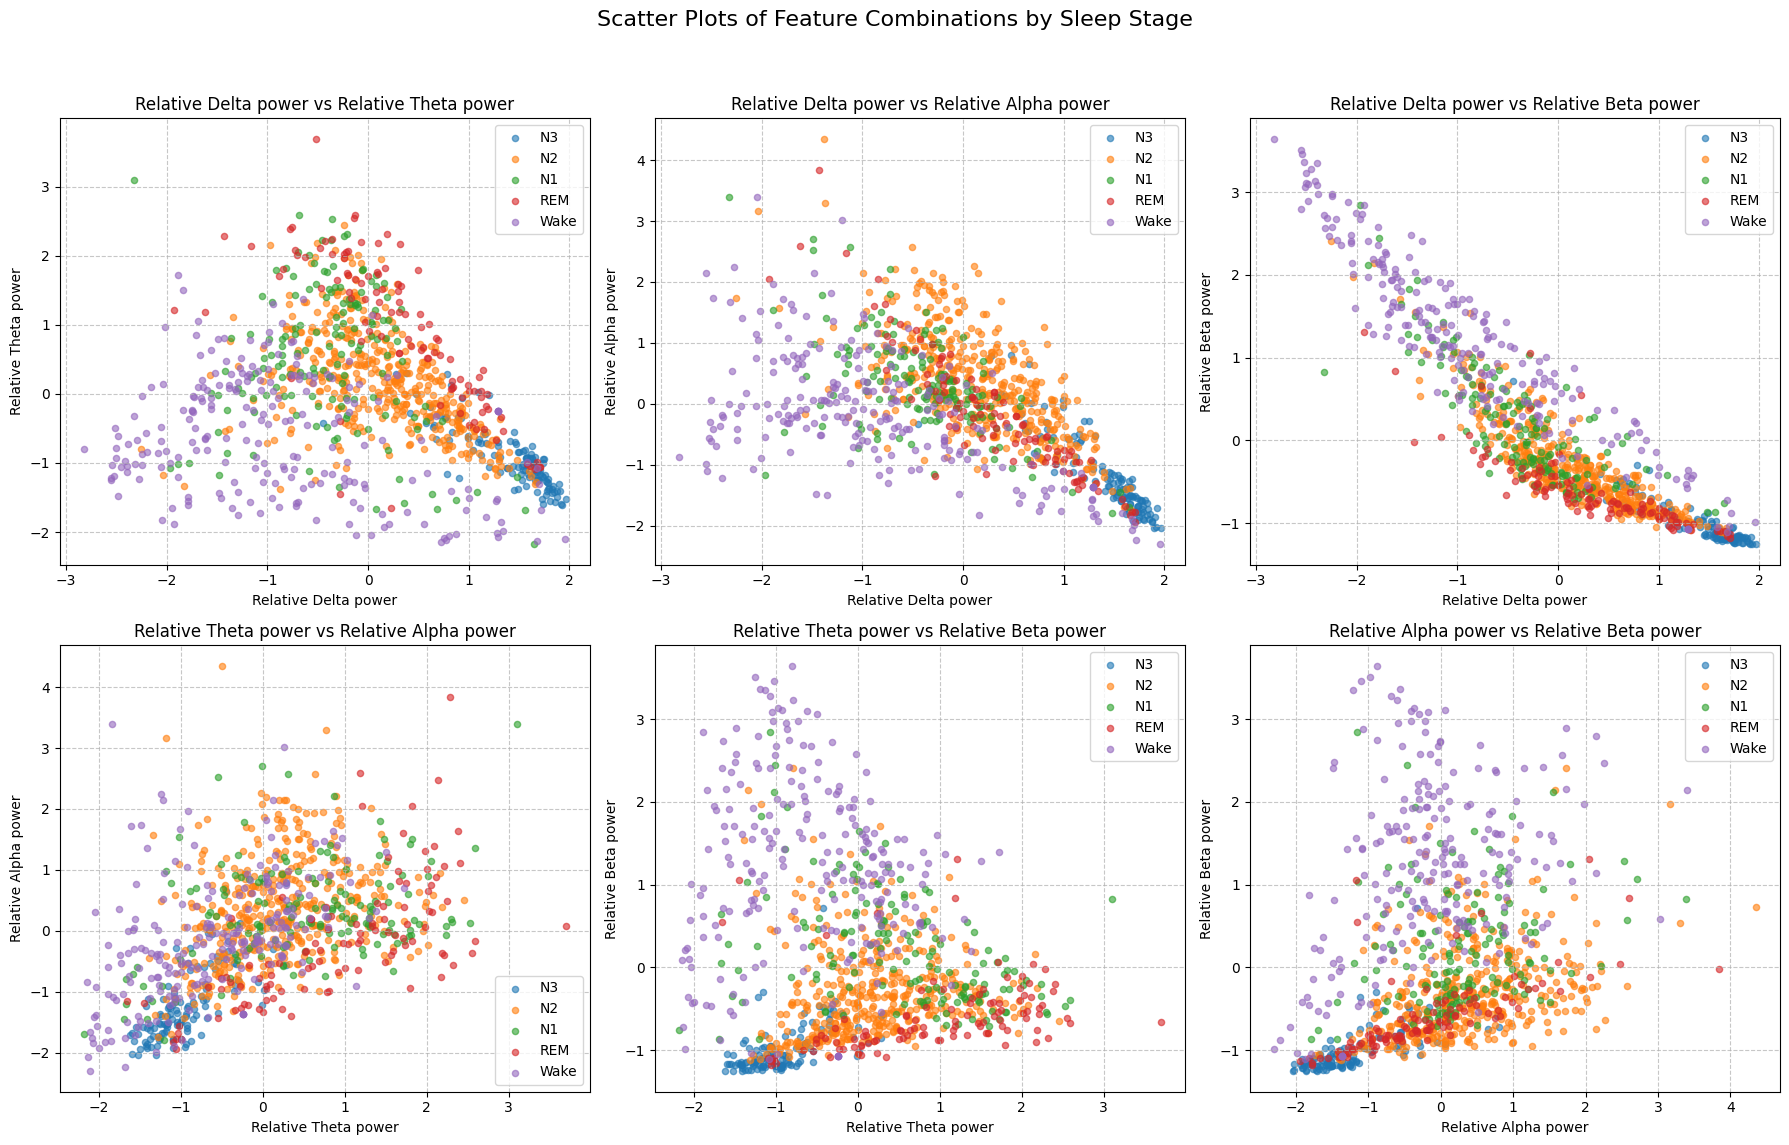

In [48]:
# Get all feature combinations (with indices of the features).

def get_feature_pairs(n_features, max_plots=None):
    """
    Generate all 2-feature combinations, optionally limiting the number.
    """
    pairs = list(itertools.combinations(range(n_features), 2))
    if max_plots is not None:
        pairs = pairs[:max_plots]
    return pairs

# Go with a for loop through the combinations and visualize the features (make 1 figure with 6 subplots).

def plot_feature_pairs(
    features,
    labels,
    feature_names,
    sleep_stages,
    feature_pairs,
    cmap_name='tab10',
    ncols=3,
    figsize=(18, 12)
):
    """
    Plot scatter plots for each feature pair, colored by sleep stage.
    """

    colors = plt.colormaps.get_cmap(cmap_name)
    n_plots = len(feature_pairs)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, (f1_idx, f2_idx) in enumerate(feature_pairs):
        ax = axes[i]

        for j, stage in enumerate(sleep_stages):
            stage_data = features[labels == (j + 1)]

            ax.scatter(
                stage_data[:, f1_idx],
                stage_data[:, f2_idx],
                c=None,
                edgecolor=colors(j),
                label=stage,
                alpha=0.6,
                s=20
            )

        ax.set_title(f"{feature_names[f1_idx]} vs {feature_names[f2_idx]}")
        ax.set_xlabel(feature_names[f1_idx])
        ax.set_ylabel(feature_names[f2_idx])
        ax.grid(True, linestyle='--', alpha=0.7)

        # Show legend only in first plot for cleanliness
        # if i == 0:
        #     ax.legend()
        ax.legend()

    # Turn off empty subplots if any
    for k in range(n_plots, len(axes)):
        axes[k].axis("off")

    fig.suptitle("Scatter Plots of Feature Combinations by Sleep Stage", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig


def visualize_all_feature_pairs(features, labels, feature_names, sleep_stages, max_plots=6):
    n_features = features.shape[1]
    pairs = get_feature_pairs(n_features, max_plots=max_plots)

    return plot_feature_pairs(
        features=features,
        labels=labels,
        feature_names=feature_names,
        sleep_stages=sleep_stages,
        feature_pairs=pairs
    )

fig = visualize_all_feature_pairs(
    features,
    labels,
    feature_names,
    sleep_stages,
    max_plots=6
)

In [49]:
def visualize_kmeans_feature_pairs(
    features,
    cluster_labels_1idx,
    feature_names,
    cluster_names,
    centroids,
    max_plots=6,
    cmap_name='tab10',
    ncols=3,
    figsize=(18, 12)
):
    pairs = get_feature_pairs(features.shape[1], max_plots=max_plots)
    colors = plt.colormaps.get_cmap(cmap_name)

    n_plots = len(pairs)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, (f1_idx, f2_idx) in enumerate(pairs):
        ax = axes[i]

        # plot cluster points
        for c, cname in enumerate(cluster_names):
            data = features[cluster_labels_1idx == (c+1)]

            ax.scatter(
                data[:, f1_idx],
                data[:, f2_idx],
                edgecolor=colors(c),
                c=None,
                s=20,
                alpha=0.6,
                label=cname
            )

            # draw centroid → point lines
            cx, cy = centroids[c, f1_idx], centroids[c, f2_idx]
            for px, py in zip(data[:, f1_idx], data[:, f2_idx]):
                ax.plot([cx, px], [cy, py], color='gray', alpha=0.1, linewidth=0.5)

        # plot centroids as X
        ax.scatter(
            centroids[:, f1_idx],
            centroids[:, f2_idx],
            marker='X',
            s=150,
            edgecolor='black',
            linewidths=2,
            facecolors='yellow',
            label='Centroid'
        )

        ax.set_title(f"{feature_names[f1_idx]} vs {feature_names[f2_idx]}")
        ax.set_xlabel(feature_names[f1_idx])
        ax.set_ylabel(feature_names[f2_idx])
        ax.grid(True, linestyle='--', alpha=0.7)

        ax.legend()

    for k in range(n_plots, len(axes)):
        axes[k].axis("off")

    fig.suptitle("K-means Clusters (k=5) in Feature Space", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig


### Cluster the data (k=5)

- **Apply k-means (k=5) clustering** to the data using the `KMeans` class (Hint: have a look at the `fit` and the `predict` methods of this class). **Visualize the result** using the same scatterplots as in task 1 (1 figure with 6 subplots), but use the cluster indices as new labels (for the colors). Mark the centroids of the clusters (Hint: have a look at the attributes of the `KMeans` class).

- **Compare the results** with the feature visualization and real labels of task 1 (the scatter plots).
    - What do you notice?


Some useful functions from the package *sklearn*:
- **cluster.KMeans**: compute K-means clustering
- **fit**: train a model on a dataset
- **predict**: predict the classes using a trained model


In [ ]:
KMeans

sklearn.cluster._kmeans.KMeans

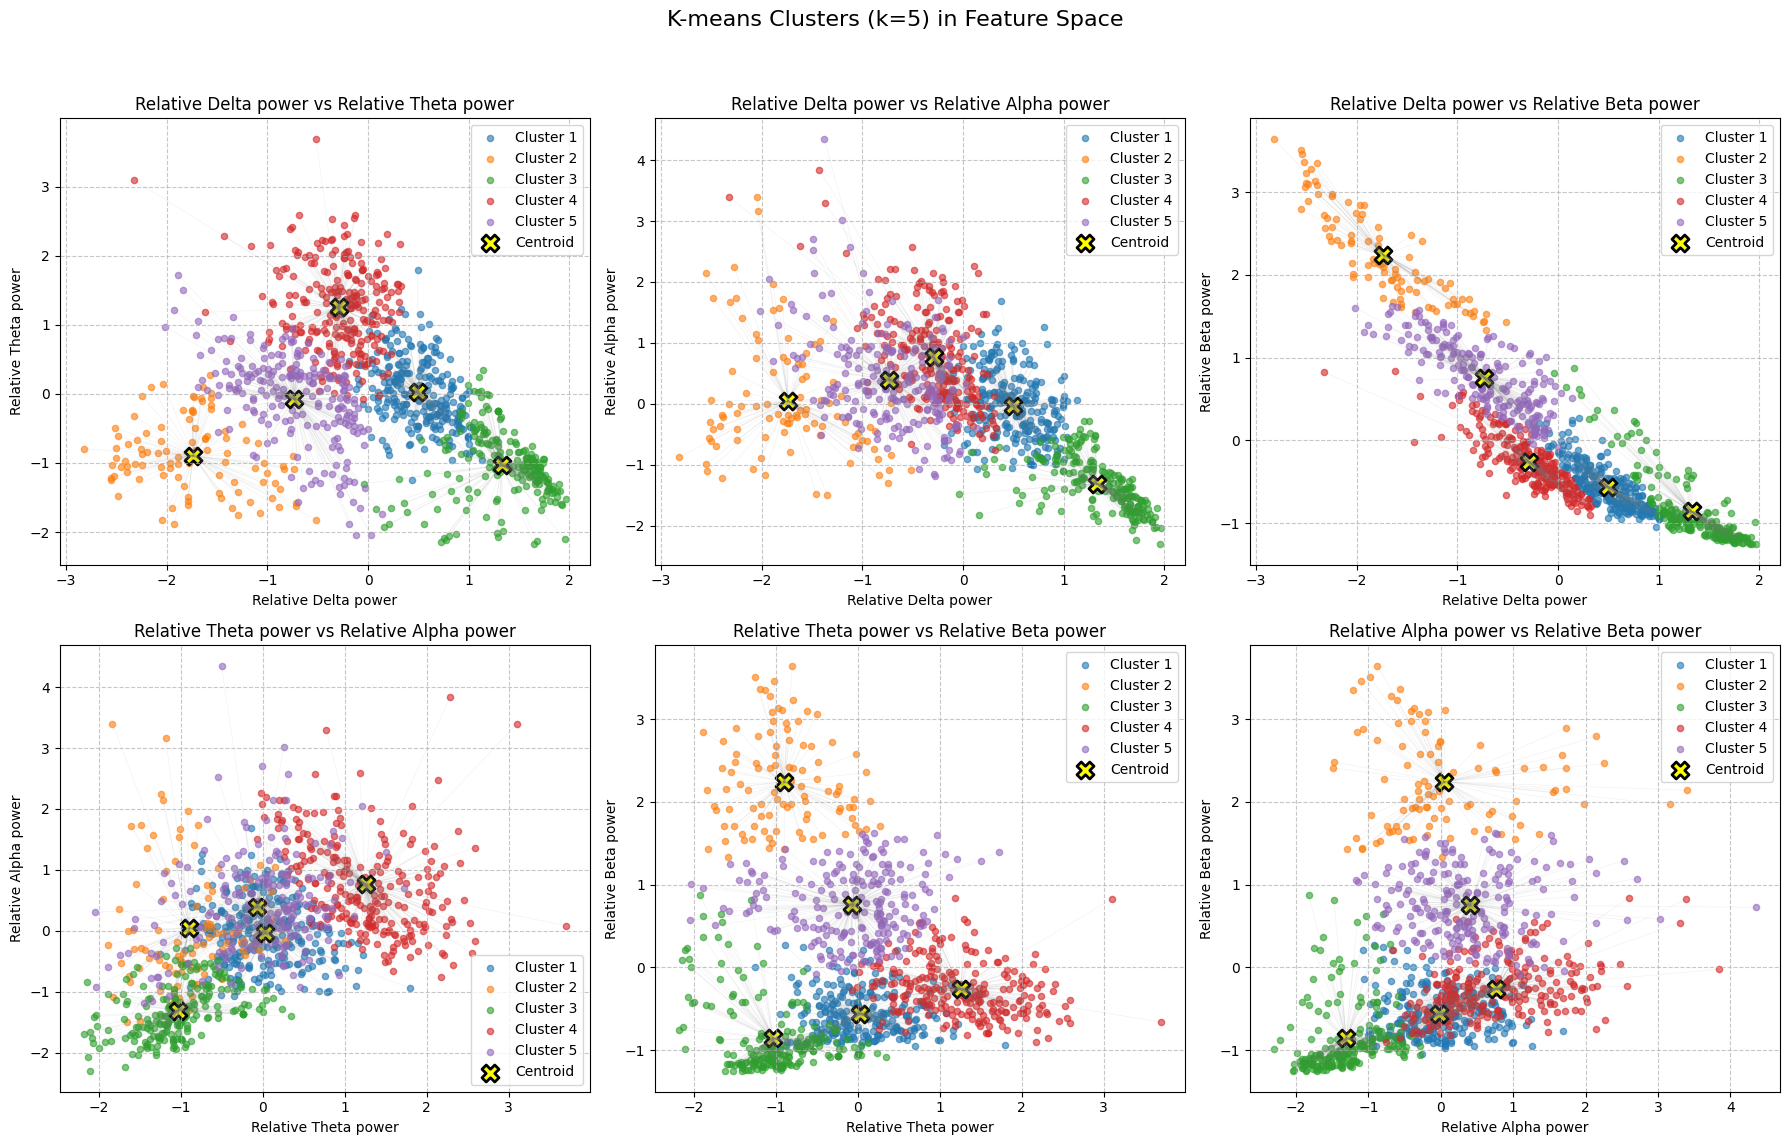

In [50]:
# Apply the K-means algorithm, with k=5 clusters
# Get the cluster centroids and indices ("Which data point belongs to which cluster?")

kmeans5 = KMeans(n_clusters=5, random_state=42, n_init="auto")
kmeans5.fit(features)

feature_names_kmeans = kmeans5.get_feature_names_out(feature_names)


cluster_labels = kmeans5.labels_          # 0..4
centroids = kmeans5.cluster_centers_      # (5, n_features)

# Convert to 1..5 (your plotting loop uses (j+1))
cluster_labels_1idx = cluster_labels + 1

# Names used in legend
cluster_names = [f"Cluster {i}" for i in range(1, 6)]

fig_kmeans = visualize_kmeans_feature_pairs(
    features=features,
    cluster_labels_1idx=cluster_labels_1idx,
    feature_names=feature_names,
    cluster_names=cluster_names,
    centroids=centroids,
    max_plots=6
)


# try plotting the features in 2d space so we have a separation.. :??

### Cluster the data (k=3)

- Repeat the procedure but by clustering the data into **3 clusters**.
    - What happens?
- **Compare the results** with the feature visualization and real labels of task 1.
    - What do you notice?



(1026, 4)


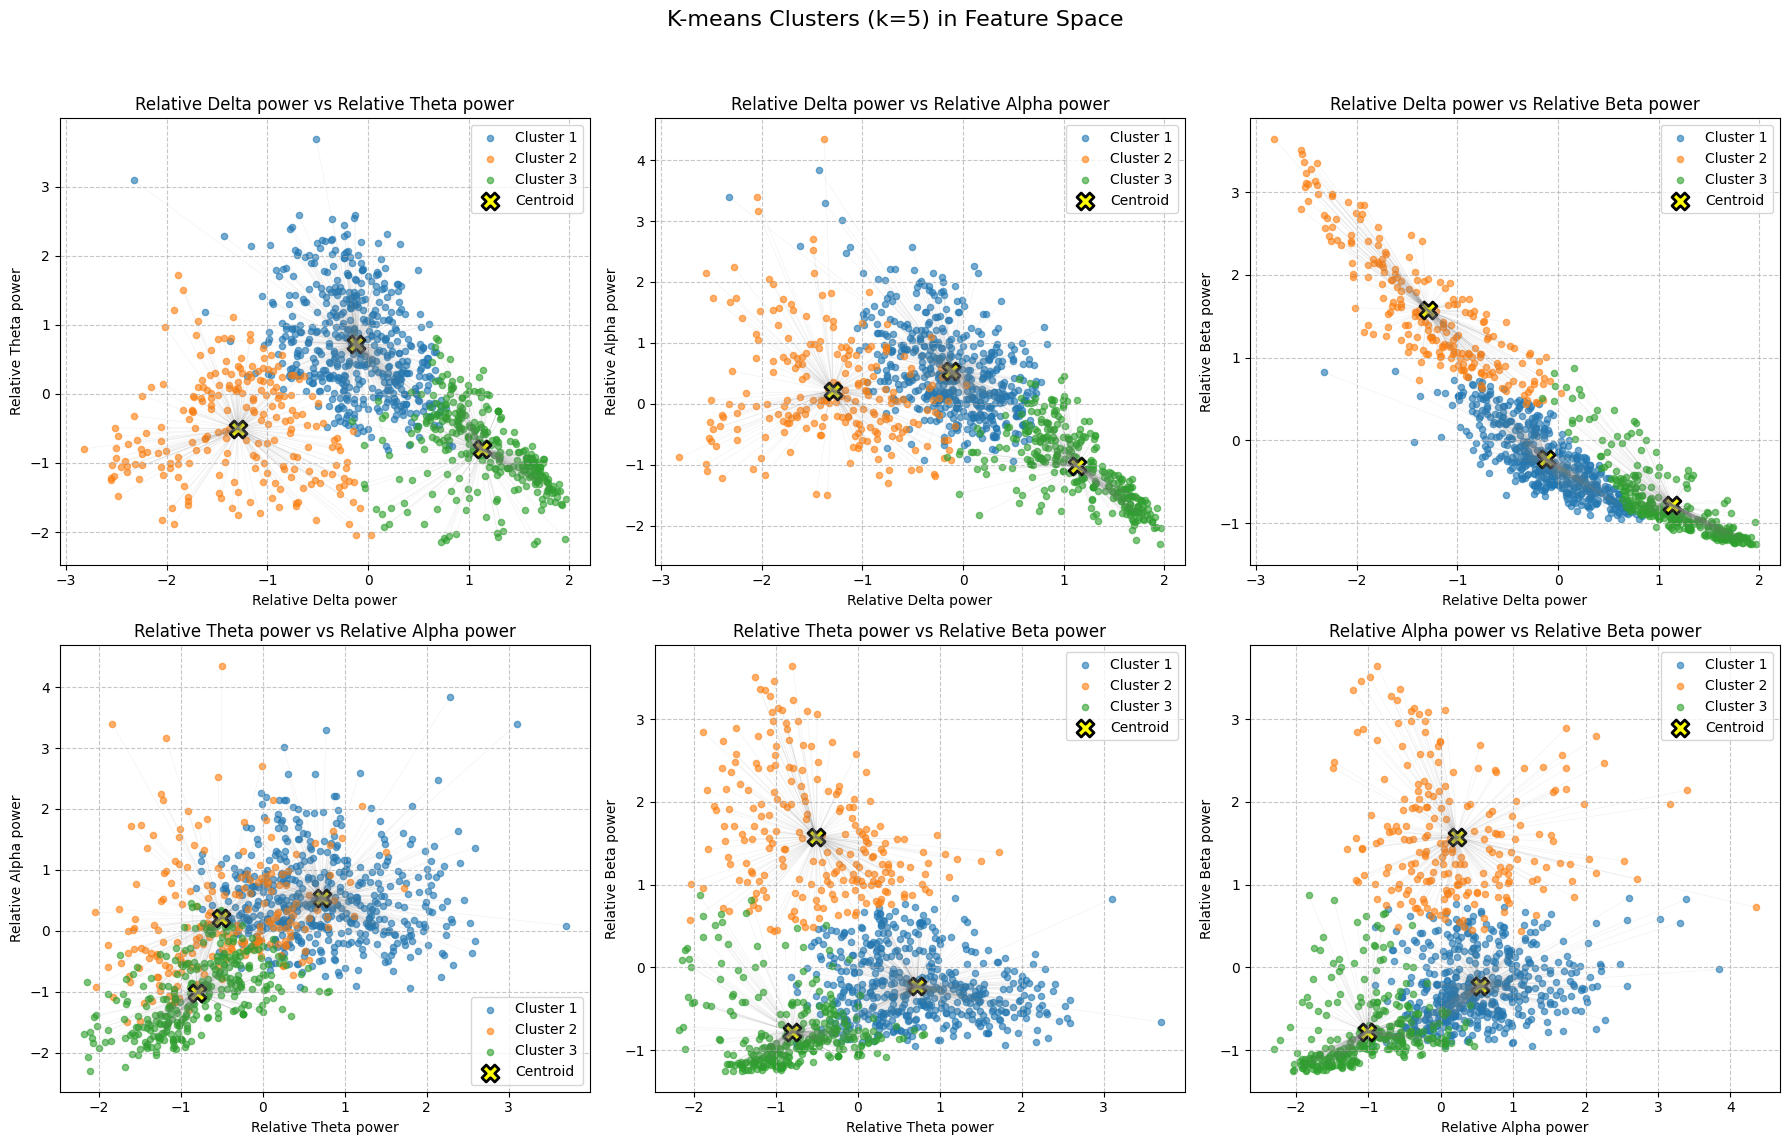

In [53]:
# Apply the K-means algorithm, with k=3 clusters
# Get the cluster centroids and indices ("Which data point belongs to which cluster?")
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
kmeans3.fit(features)

cluster_labels3 = kmeans3.labels_           # shape: (n_samples,)
centroids3 = kmeans3.cluster_centers_       # shape: (k, n_features)
feature_names_kmeans = kmeans3.get_feature_names_out(feature_names)

cluster_labels_1idx3 = cluster_labels3 + 1
print(features.shape)

# Names used in legend
cluster_names = [f"Cluster {i}" for i in range(1, 4)] # Changed range from 1,6 to 1,4 to match n_clusters=3

fig_kmeans = visualize_kmeans_feature_pairs(
    features=features,
    cluster_labels_1idx=cluster_labels_1idx3,
    feature_names=feature_names,
    cluster_names=cluster_names,
    centroids=centroids3,
    max_plots=6
)

### Calculate the within-cluster sums of data point to centroid distances

Compute the **sum of the squared Euclidean distances between each data point and its cluster centroid**. (Hint: have a look at the attributes of the `KMeans` algorithm object)
- What do we learn from these within-cluster sums of data point to centroid distances?

In [54]:
#  inertia_ : float
#     Sum of squared distances of samples to their closest cluster center,
#     weighted by the sample weights if provided.
print("WSS of kmeans with k=5", kmeans5.inertia_)
print("WSS of kmeans with k=3", kmeans3.inertia_)

WSS of kmeans with k=5 1135.0043868987764
WSS of kmeans with k=3 1582.1344528215946
